# 5c_SIM_TARGETS — Similarity Prediction on Target Grids

Apply the trained Similarity (kernel regression) model to Antarctic and Greenland target grids.

**Outputs per region:**

| Variable | Description |
|---|---|
| `sim_q_raw` | Raw weighted-mean prediction |
| `sim_q_corr` | Spline-corrected mean |
| `sim_std_raw` | Weighted std of reference distribution (raw) |
| `sim_std_corr` | Std after spline correction (propagated offset) |
| `sim_lo_raw/corr` | q_mean ± std lower bound |
| `sim_hi_raw/corr` | q_mean ± std upper bound |
| `sim_N` | Mean N_sim (effective neighbourhood size) |
| `sim_shannon_H` | Normalised Shannon entropy of per-point histogram (scalar attribute) |

**Histogram:** Per-point weighted PDF stored as 3D variable `sim_hist` (y, x, bin).
Bins: `HIST_BIN_WIDTH = 0.010` W/m², range `[Q_CLIP_MIN, q_clip_max]`.

**Batching:** Target points are processed in batches of `BATCH_SIZE = 10000`
to keep the similarity matrix (`batch × n_ref × n_feat`) within memory.

**Files written:**
- `output/targets/Aq15_SIM_v{MODEL_VERSION}.nc` — Antarctica
- `output/targets/Kq15_SIM_v{MODEL_VERSION}.nc` — Greenland

> Requires: `output/models/sim_artefacts.pkl` (written by `4c_SIM_MODEL`)

## 1. Imports & constants

In [1]:
import sys, json, pickle, warnings, datetime, time
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from scipy.stats import entropy as scipy_entropy
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
from config import (
    obs_model, q_clip_max, q_clip_min, random_state,
    model_dir, targets_dir, param_paths,
    netcdf_compression_level, NETCDF_AUTHOR, NETCDF_CONVENTIONS,
    TARGET_GRIDS, MODEL_VERSION,
)
sys.path.insert(0, 'lib')
from similarity import similarity_predict

from lib.utils import grid_from_xr_dataset

targets_dir.mkdir(parents=True, exist_ok=True)

# ── Histogram parameters (must match similarity.py constants) ─────────────────
HIST_BIN_WIDTH = 0.010          # [W/m²]
HIST_MAX_BINS  = 400
BATCH_SIZE     = 10_000         # target points per batch

n_bins = int(min((q_clip_max - q_clip_min) / HIST_BIN_WIDTH, HIST_MAX_BINS))
bin_edges = np.linspace(q_clip_min, q_clip_max, n_bins + 1)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

print(f'model version : {MODEL_VERSION}')
print(f'targets_dir   : {targets_dir}')
print(f'hist n_bins   : {n_bins}  bin_width={HIST_BIN_WIDTH} W/m²')
print(f'batch size    : {BATCH_SIZE:,} points')

✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
model version : 0_4
targets_dir   : output/targets
hist n_bins   : 34  bin_width=0.01 W/m²
batch size    : 10,000 points


## 2. Helpers

In [2]:
def load_grid(grid_cfg, obs_sel):
    """Load target parquet, validate features, report grid shape."""
    label = grid_cfg['label']
    df    = pd.read_parquet(grid_cfg['parquet'])
    print(f'\n[{label.upper()}] {len(df):,} rows')
    missing = [f for f in obs_sel if f not in df.columns]
    if missing:
        warnings.warn(f'Missing features {missing} — filling NaN')
        for f in missing:
            df[f] = np.nan
    nan_cols = {f: int(df[f].isna().sum()) for f in obs_sel if df[f].isna().any()}
    if nan_cols:
        print(f'  NaN counts: {nan_cols}')
    else:
        print(f'  All {len(obs_sel)} features OK, no NaNs')
    xcol, ycol = grid_cfg['x_col'], grid_cfg['y_col']
    x_vals = np.sort(df[xcol].unique()).astype(np.float64)
    y_vals = np.sort(df[ycol].unique()).astype(np.float64)
    nx, ny = len(x_vals), len(y_vals)
    is_reg = (len(df) == nx * ny)
    if is_reg:
        dx = np.diff(x_vals)
        dy = np.diff(y_vals)
        print(f'  Regular {ny}x{nx}  dx={dx[0]:.0f}m  dy={dy[0]:.0f}m')
    else:
        print(f'  Irregular {len(df):,} pts (expected {ny*nx:,})')
    return df, x_vals, y_vals, ny, nx, is_reg


def build_X(df, obs_sel, scaler):
    """Scale features; return (X_sc, finite_mask)."""
    X_raw  = df[obs_sel].values.astype(np.float32)
    finite = np.isfinite(X_raw).all(axis=1)
    X_sc   = np.full_like(X_raw, np.nan)
    if finite.any():
        X_sc[finite] = scaler.transform(X_raw[finite]).astype(np.float32)
    print(f'  finite points: {finite.sum():,} / {len(df):,}')
    return X_sc, finite


def to_2d(vals_1d, df, x_vals, y_vals, xcol, ycol, is_reg):
    """Reshape flat 1-D array to (ny, nx) grid."""
    from scipy.interpolate import griddata
    ny, nx = len(y_vals), len(x_vals)
    if is_reg:
        tmp = df[[xcol, ycol]].copy()
        tmp['_v'] = vals_1d
        return tmp.pivot(index=ycol, columns=xcol, values='_v').values.astype(np.float32)
    gx, gy = np.meshgrid(x_vals, y_vals)
    return griddata(df[[xcol, ycol]].values, vals_1d,
                    (gx, gy), method='nearest').astype(np.float32)


def apply_spline(spline, vals):
    """Apply PCHIP spline with clipping."""
    out    = np.full(vals.shape, np.nan, dtype=np.float32)
    ok     = np.isfinite(vals)
    out[ok] = np.clip(spline(vals[ok]).astype(np.float32), q_clip_min, q_clip_max)
    return out


def shannon_H_norm(hist_2d, bin_width=HIST_BIN_WIDTH):
    """Normalised Shannon entropy of a 2D field of per-point histograms (n_pts, n_bins).
    Returns a scalar: mean normalised entropy over all finite points."""
    # hist_2d shape: (n_pts, n_bins), each row is a normalised PDF * dq
    # convert to probability mass per bin: p = hist * dq (already done in similarity_predict)
    row_sums = hist_2d.sum(axis=1)                         # should be ~1/dq per row
    valid    = row_sums > 0
    if not valid.any():
        return np.nan
    p = hist_2d[valid] * bin_width                         # probability mass
    p = np.clip(p, 1e-12, None)
    p = p / p.sum(axis=1, keepdims=True)                   # renormalise
    H_arr   = -np.sum(p * np.log(p), axis=1)               # Shannon H per point
    H_max   = np.log(n_bins)
    return float(np.mean(H_arr / H_max)) if H_max > 0 else 0.0


def make_ds(arrays, hist_3d, x_vals, y_vals, bin_centres_arr,
            grid_cfg, params, obs_sel_used, model_tag, extra=None):
    """Build xarray Dataset with all 2D arrays + 3D histogram."""
    coords = {'y': y_vals, 'x': x_vals}
    dvars  = {
        name: xr.DataArray(arr, dims=['y', 'x'], coords=coords,
                           attrs={'units': 'W m-2',
                                  'long_name': name.replace('_', ' ')})
        for name, arr in arrays.items()
    }
    # 3D histogram: (y, x, bin)
    if hist_3d is not None:
        ny, nx = len(y_vals), len(x_vals)
        dvars['sim_hist'] = xr.DataArray(
            hist_3d,
            dims=['y', 'x', 'bin'],
            coords={**coords, 'bin': bin_centres_arr},
            attrs={'units'     : 'W m-2 bin-1',
                   'long_name' : 'weighted similarity PDF per target point',
                   'bin_width' : HIST_BIN_WIDTH}
        )
    ds = xr.Dataset(dvars, coords=coords)
    attrs = dict(
        title        = f'{model_tag} heat-flow prediction',
        model        = model_tag,
        version      = MODEL_VERSION,
        institution  = NETCDF_AUTHOR,
        Conventions  = NETCDF_CONVENTIONS,
        crs          = grid_cfg['crs'],
        epsg         = str(grid_cfg['epsg']),
        region       = grid_cfg['label'].upper(),
        created      = datetime.datetime.utcnow().isoformat() + 'Z',
        obs_sel      = json.dumps(obs_sel_used),
        params_json  = json.dumps(params, default=str),
        hist_bin_width = HIST_BIN_WIDTH,
        hist_n_bins    = n_bins,
        q_clip_min     = float(q_clip_min),
        q_clip_max     = float(q_clip_max),
    )
    if extra:
        attrs.update(extra)
    ds.attrs = attrs
    return ds


def save_nc(ds, path):
    enc = {v: {'zlib': True, 'complevel': netcdf_compression_level, 'dtype': 'float32'}
           for v in ds.data_vars}
    ds.to_netcdf(path, encoding=enc)
    print(f'  Saved {path}  ({path.stat().st_size / 1e6:.1f} MB)')


print('Helpers ready.')

Helpers ready.


## 3. Load Similarity artefacts

In [3]:
with open(model_dir / 'sim_artefacts.pkl', 'rb') as fp:
    art = pickle.load(fp)

obs_sel   = art['obs_sel']          # feature list used in training
scaler    = art['scaler']           # StandardScaler fitted on train fold
X_ref     = art['X_tr_ref']         # (n_ref, n_feat) scaled reference features
H_ref     = art['y_tr_ref']         # (n_ref,)  reference heat-flow
W_ref     = art.get('w_tr_ref', np.ones(len(H_ref), dtype=np.float32))
sigma_arr = art['sigma_arr']        # (n_feat,) optimised bandwidths
K         = float(art['K'])
sim_spline= art['sim_spline']       # PCHIP correction spline
PARAMS    = art['PARAMS']

n_ref, n_feat = X_ref.shape
print(f'Similarity artefacts loaded')
print(f'  n_ref     : {n_ref:,}  n_feat={n_feat}')
print(f'  K         : {K:.4f}')
print(f'  sigma_arr : [{sigma_arr.min():.3f}, {sigma_arr.max():.3f}]')
print(f'  obs_sel   : {obs_sel}')

Similarity artefacts loaded
  n_ref     : 24,677  n_feat=22
  K         : 20.0000
  sigma_arr : [0.273, 3.154]
  obs_sel   : ['REVEAL_VP60VS70', 'REVEAL_S100', 'REVEAL_P150', 'FREE_AIR', 'CTD', 'REVEAL_S70', 'MAG_SEIS_MOHO', 'BOUGUER', 'LITH_RHO', 'DEM', 'MOHO_GRAV', 'GEOID', 'REVEAL_VP90VS60', 'REVEAL_S90', 'LAB', 'REVEAL_S80', 'SEDIMENT', 'REVEAL_VP50VS80', 'CRUST_RHO', 'MOHO', 'SI', 'EMAG2_LOG']


## 4. Batched predict & write NetCDF

For each target region:
1. Load parquet, validate features
2. Scale features with train-fold scaler
3. Loop over batches of `BATCH_SIZE` finite points, calling `similarity_predict` with `hist=True`
4. Apply PCHIP spline to `sim_q_raw` → `sim_q_corr`; propagate offset to bounds
5. Reshape to 2D and write compressed NetCDF

In [4]:
SIM_KERNEL = PARAMS.get('SIM_KERNEL', 'rbf')
SIM_WEIGHT_MODE = PARAMS.get('SIM_WEIGHT_MODE', 'shifted_exp')
print(f"Similarity mode: kernel={SIM_KERNEL} | weight_mode={SIM_WEIGHT_MODE}")

results_sim = {}


K = 10 #Hardcoded here but should match value used in similarity_predict (from sim_artefacts.pkl)

for grid_cfg in TARGET_GRIDS:
    label = grid_cfg['label']
    prefix = 'Aq15' if label == 'ant' else 'Kq15'
    out_path = targets_dir / f'{prefix}_SIM_v{MODEL_VERSION}.nc'
    xcol, ycol = grid_cfg['x_col'], grid_cfg['y_col']

    df, x_vals, y_vals, ny, nx, is_reg = load_grid(grid_cfg, obs_sel)
    X_sc, finite = build_X(df, obs_sel, scaler)

    n_tgt = len(df)
    n_finite = finite.sum()

    q_raw_1d = np.full(n_tgt, np.nan, dtype=np.float32)
    std_1d = np.full(n_tgt, np.nan, dtype=np.float32)
    N_1d = np.full(n_tgt, np.nan, dtype=np.float32)
    hist_1d = np.zeros((n_tgt, n_bins), dtype=np.float32)

    finite_idx = np.where(finite)[0]
    X_finite = X_sc[finite_idx]

    n_batches = int(np.ceil(n_finite / BATCH_SIZE))
    print(f' Predicting {n_finite:,} finite points in {n_batches} batches of {BATCH_SIZE:,} ...')

    t0 = time.time()
    for b in range(n_batches):
        i0 = b * BATCH_SIZE
        i1 = min(i0 + BATCH_SIZE, n_finite)
        X_batch = X_finite[i0:i1]
        W_t_batch = np.ones(len(X_batch), dtype=np.float32)

        q_b, std_b, N_b, hist_b = similarity_predict(
            X_ref = X_ref,
            H_ref = H_ref,
            X_tgt = X_batch,
            W_t = W_t_batch,
            S_r = sigma_arr,
            K = K,
            W_r = W_ref,
            hist = True,
            n_bins = n_bins,
            q_min = float(q_clip_min),
            q_max = float(q_clip_max),
            use_sigma_helper = False,
            kernel      = 'rbf',     
             weight_mode = 'shifted_exp', 
        )

        idx_slice = finite_idx[i0:i1]
        q_raw_1d[idx_slice] = q_b.astype(np.float32)
        std_1d[idx_slice] = std_b.astype(np.float32)
        N_1d[idx_slice] = N_b.astype(np.float32)
        hist_1d[idx_slice] = hist_b.astype(np.float32)

        elapsed = time.time() - t0
        eta = elapsed / (i1) * (n_finite - i1) if i1 > 0 else 0
        print(f' batch {b+1:3d}/{n_batches} pts {i1:>7,}/{n_finite:,} '
              f'elapsed={elapsed/60:.1f}min ETA={eta/60:.1f}min')

    print(f' Total wall time: {(time.time()-t0)/60:.1f} min')

    q_raw_1d = np.clip(q_raw_1d, q_clip_min, q_clip_max)
    q_corr_1d = apply_spline(sim_spline, q_raw_1d)
    offset_1d = np.where(np.isfinite(q_corr_1d), q_corr_1d - q_raw_1d, 0.0).astype(np.float32)

    std_corr_1d = std_1d.copy()
    lo_raw_1d = np.clip(q_raw_1d - std_1d, q_clip_min, q_clip_max)
    hi_raw_1d = np.clip(q_raw_1d + std_1d, q_clip_min, q_clip_max)
    lo_corr_1d = np.clip(q_corr_1d - std_corr_1d, q_clip_min, q_clip_max)
    hi_corr_1d = np.clip(q_corr_1d + std_corr_1d, q_clip_min, q_clip_max)

    H_mean = shannon_H_norm(hist_1d[finite_idx])
    print(f' Shannon H (norm, mean over grid): {H_mean:.4f}')

    def r2(v):
        return to_2d(v, df, x_vals, y_vals, xcol, ycol, is_reg)

    arrays = {
        'sim_q_raw' : r2(q_raw_1d),
        'sim_q_corr' : r2(q_corr_1d),
        'sim_std_raw' : r2(std_1d),
        'sim_std_corr': r2(std_corr_1d),
        'sim_lo_raw' : r2(lo_raw_1d),
        'sim_hi_raw' : r2(hi_raw_1d),
        'sim_lo_corr' : r2(lo_corr_1d),
        'sim_hi_corr' : r2(hi_corr_1d),
        'sim_N' : r2(N_1d),
    }

    if is_reg:
        tmp = df[[xcol, ycol]].copy().reset_index(drop=True)
        tmp['_row'] = tmp[ycol].map({v: i for i, v in enumerate(y_vals)})
        tmp['_col'] = tmp[xcol].map({v: i for i, v in enumerate(x_vals)})
        hist_3d = np.full((ny, nx, n_bins), np.nan, dtype=np.float32)
        rows = tmp['_row'].values
        cols = tmp['_col'].values
        hist_3d[rows, cols, :] = hist_1d
    else:
        from scipy.interpolate import griddata
        gx, gy = np.meshgrid(x_vals, y_vals)
        hist_3d = np.stack([
            griddata(df[[xcol, ycol]].values, hist_1d[:, b],
                     (gx, gy), method='nearest').astype(np.float32)
            for b in range(n_bins)
        ], axis=-1)

    ds = make_ds(
        arrays = arrays,
        hist_3d = hist_3d,
        x_vals = x_vals,
        y_vals = y_vals,
        bin_centres_arr = bin_centres,
        grid_cfg = grid_cfg,
        params = PARAMS,
        obs_sel_used = obs_sel,
        model_tag = f'{prefix}_SIM',
        extra = {'shannon_H_mean': H_mean,
                 'spline_applied': 'sim_q_corr, sim_lo_corr, sim_hi_corr'},
    )

    grid_cfg['agrid'] = grid_from_xr_dataset(ds, name = label)

    save_nc(ds, out_path)
    results_sim[label] = ds
    print(f' [{label.upper()}] done.')

print('All Similarity target grids complete.')


Similarity mode: kernel=rbf | weight_mode=shifted_exp

[ANT] 1,779,556 rows
  NaN counts: {'DEM': 383490}
  Regular 1334x1334  dx=5000m  dy=5000m
  finite points: 1,396,066 / 1,779,556
 Predicting 1,396,066 finite points in 140 batches of 10,000 ...
 batch   1/140 pts  10,000/1,396,066 elapsed=0.1min ETA=20.0min
 batch   2/140 pts  20,000/1,396,066 elapsed=0.3min ETA=20.1min
 batch   3/140 pts  30,000/1,396,066 elapsed=0.4min ETA=19.9min
 batch   4/140 pts  40,000/1,396,066 elapsed=0.6min ETA=19.7min
 batch   5/140 pts  50,000/1,396,066 elapsed=0.7min ETA=19.6min
 batch   6/140 pts  60,000/1,396,066 elapsed=0.9min ETA=19.5min
 batch   7/140 pts  70,000/1,396,066 elapsed=1.0min ETA=19.3min
 batch   8/140 pts  80,000/1,396,066 elapsed=1.2min ETA=19.2min
 batch   9/140 pts  90,000/1,396,066 elapsed=1.3min ETA=19.1min
 batch  10/140 pts 100,000/1,396,066 elapsed=1.5min ETA=18.9min
 batch  11/140 pts 110,000/1,396,066 elapsed=1.6min ETA=18.8min
 batch  12/140 pts 120,000/1,396,066 elapsed=1

In [5]:
# ds.to_netcdf('sim.nc')

## 5. Summary statistics

In [6]:
for label, ds in results_sim.items():
    print(f'\n[{label.upper()}] variables:')
    for v in ds.data_vars:
        if v == 'sim_hist':
            print(f'  {v:25s} shape={ds[v].shape}')
            continue
        arr = ds[v].values
        fin = arr[np.isfinite(arr)]
        if fin.size == 0:
            print(f'  {v:25s} all NaN')
            continue
        print(f'  {v:25s} mean={fin.mean()*1e3:.1f}  '
              f'std={fin.std()*1e3:.1f}  '
              f'[{fin.min()*1e3:.1f}, {fin.max()*1e3:.1f}] mW/m²')


[ANT] variables:
  sim_q_raw                 mean=60.0  std=14.9  [2.0, 210.2] mW/m²
  sim_q_corr                mean=55.7  std=18.6  [3.2, 245.2] mW/m²
  sim_std_raw               mean=28.5  std=17.4  [0.0, 126.2] mW/m²
  sim_std_corr              mean=28.5  std=17.4  [0.0, 126.2] mW/m²
  sim_lo_raw                mean=31.6  std=12.7  [1.0, 134.3] mW/m²
  sim_hi_raw                mean=88.4  std=29.7  [2.0, 291.2] mW/m²
  sim_lo_corr               mean=27.4  std=14.0  [1.0, 164.4] mW/m²
  sim_hi_corr               mean=84.2  std=33.0  [3.2, 328.5] mW/m²
  sim_N                     mean=0.1  std=0.1  [0.0, 1.2] mW/m²
  sim_hist                  shape=(1334, 1334, 34)

[GRL] variables:
  sim_q_raw                 mean=62.3  std=19.2  [7.7, 305.9] mW/m²
  sim_q_corr                mean=58.7  std=23.7  [1.0, 301.5] mW/m²
  sim_std_raw               mean=22.5  std=14.4  [0.0, 139.6] mW/m²
  sim_std_corr              mean=22.5  std=14.4  [0.0, 139.6] mW/m²
  sim_lo_raw                mean=

## 6. Quick maps

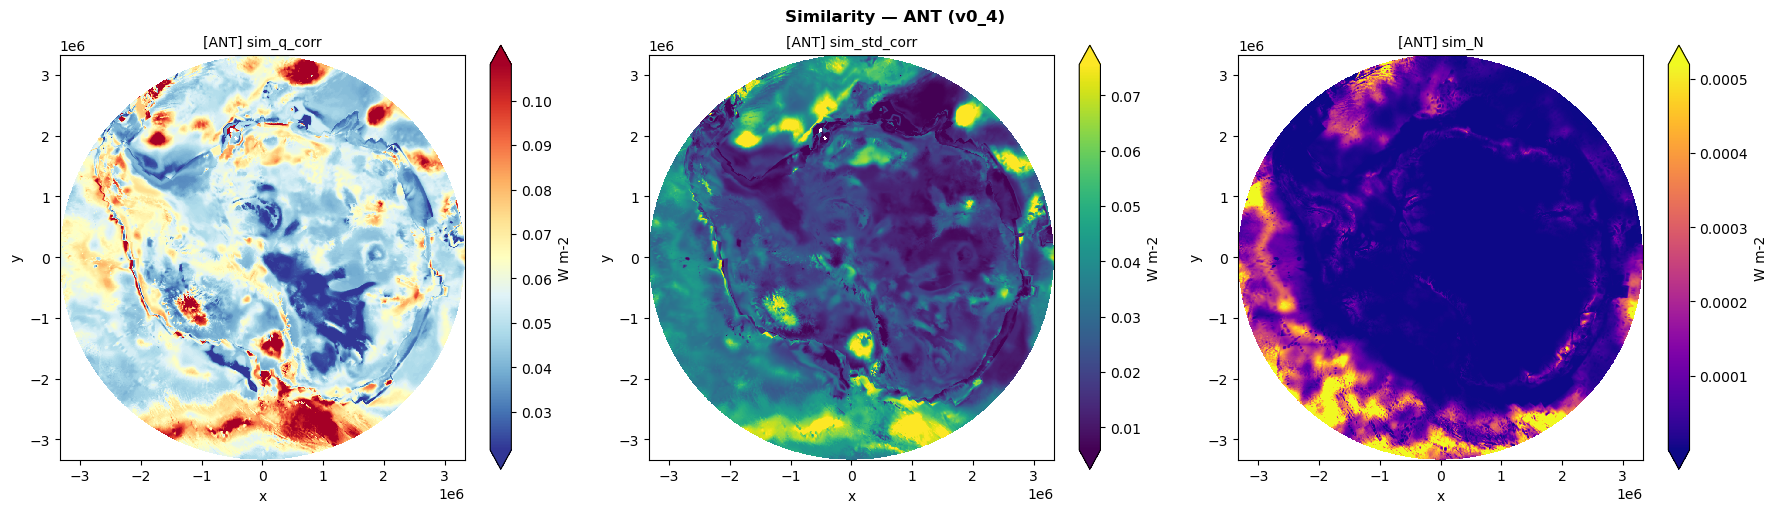

[ANT] maps done.


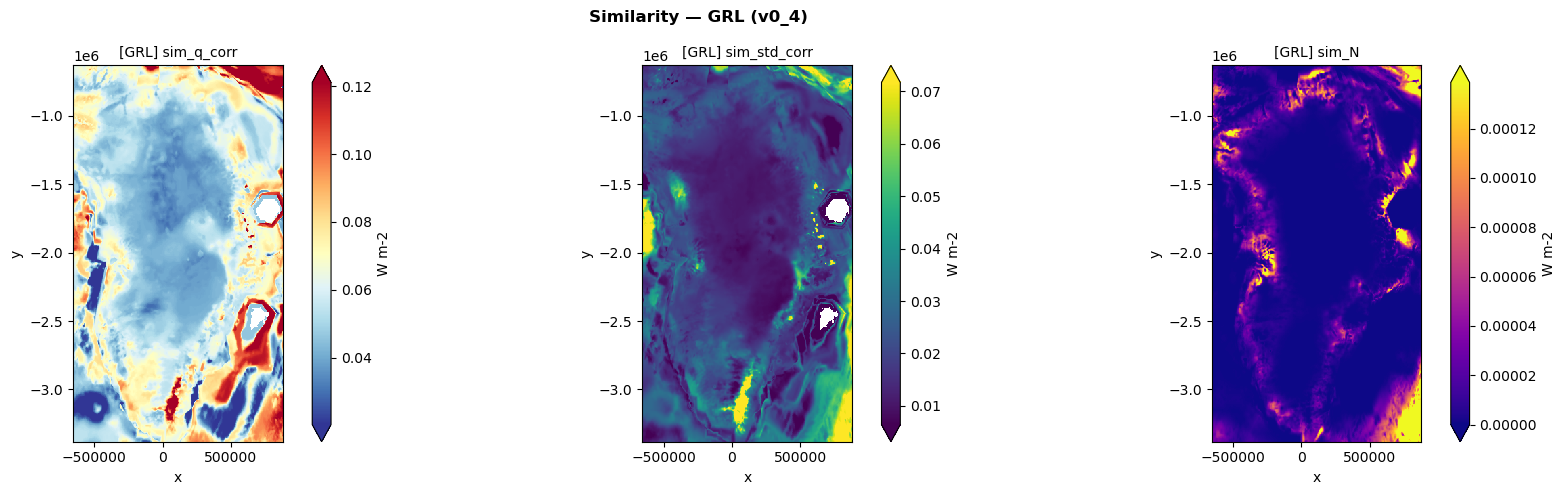

[GRL] maps done.


In [7]:
import matplotlib.pyplot as plt

plot_vars = ['sim_q_corr', 'sim_std_corr', 'sim_N']
cmaps     = ['RdYlBu_r',   'viridis',      'plasma']

for label, ds in results_sim.items():
    fig, axes = plt.subplots(1, len(plot_vars), figsize=(18, 5))
    for ax, var, cmap in zip(axes, plot_vars, cmaps):
        if var not in ds:
            continue
        vmin = float(np.nanpercentile(ds[var].values, 2))
        vmax = float(np.nanpercentile(ds[var].values, 98))
        ds[var].plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                     cbar_kwargs={'label': ds[var].attrs.get('units', '')})
        ax.set_title(f'[{label.upper()}] {var}', fontsize=10)
        ax.set_aspect('equal')
    fig.suptitle(f'Similarity — {label.upper()} (v{MODEL_VERSION})',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()
    print(f'[{label.upper()}] maps done.')

## 7. Histogram spot-check

Plot per-point histograms for a random sample of target points to verify the output PDF shapes.

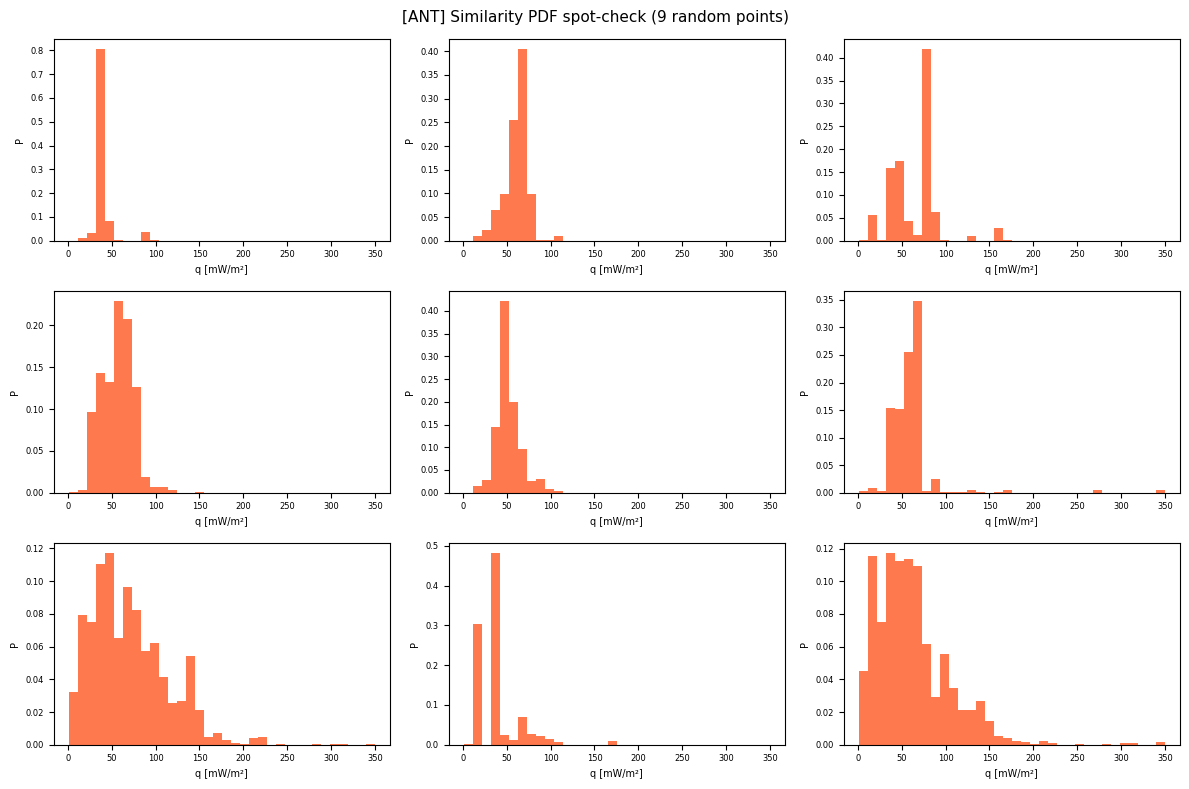

[ANT] histogram spot-check done.


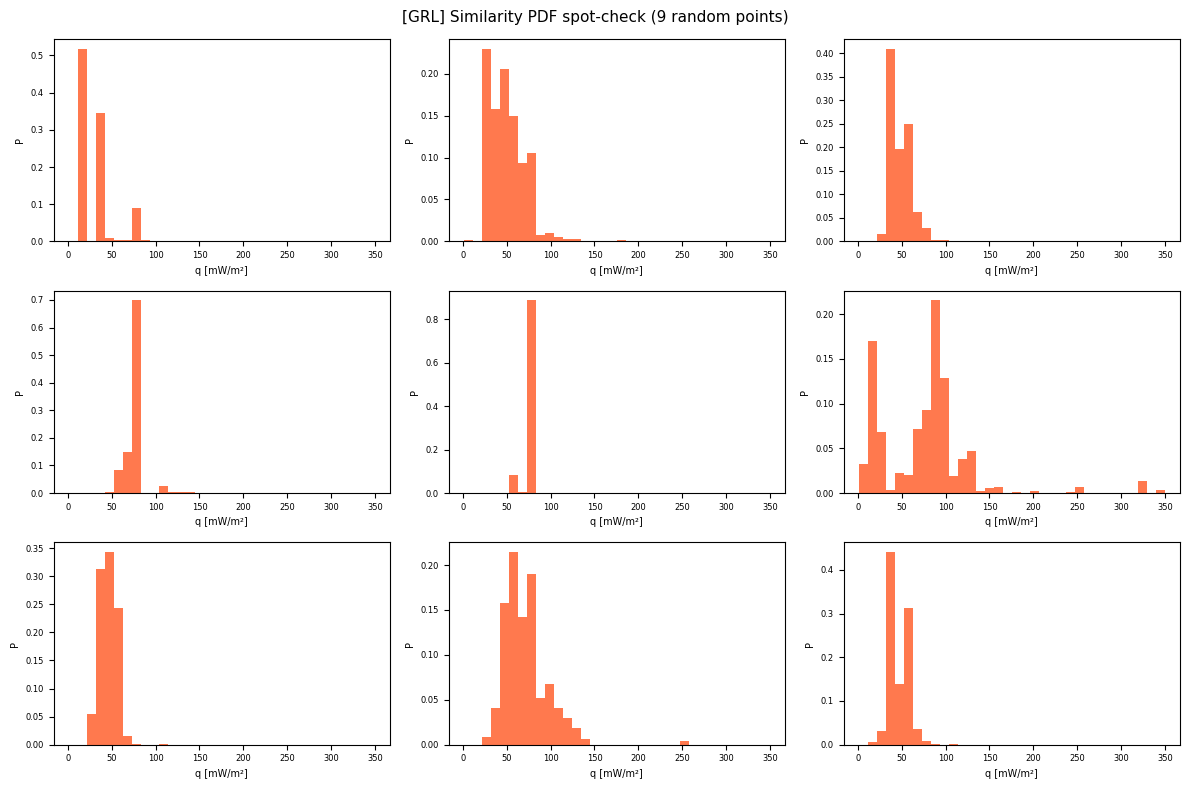

[GRL] histogram spot-check done.


In [8]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

for label, ds in results_sim.items():
    if 'sim_hist' not in ds:
        continue
    hist_arr = ds['sim_hist'].values          # (ny, nx, n_bins)
    ny, nx, nb = hist_arr.shape
    flat_hist = hist_arr.reshape(-1, nb)

    # pick 9 random finite-histogram points
    row_sums  = flat_hist.sum(axis=1)
    valid_idx = np.where(row_sums > 0)[0]
    n_show    = min(9, len(valid_idx))
    sample    = rng.choice(valid_idx, n_show, replace=False)

    fig, axes = plt.subplots(3, 3, figsize=(12, 8))
    for ax, idx in zip(axes.ravel(), sample):
        ax.bar(bin_centres * 1e3, flat_hist[idx] * HIST_BIN_WIDTH,
               width=HIST_BIN_WIDTH * 1e3, color='#FF5722', alpha=0.8)
        ax.set_xlabel('q [mW/m²]', fontsize=7)
        ax.set_ylabel('P', fontsize=7)
        ax.tick_params(labelsize=6)
    fig.suptitle(f'[{label.upper()}] Similarity PDF spot-check (9 random points)',
                 fontsize=11)
    fig.tight_layout()
    plt.show()
    print(f'[{label.upper()}] histogram spot-check done.')

In [9]:
TARGET_GRIDS[0]['agrid'].map('sim_q_raw', cmap = hf_cmap, vmin = q_min, vmax = q_max)

NameError: name 'hf_cmap' is not defined

In [ ]:
from config import *